# California Models — Gap Fixes

Addresses three gaps identified in `california_models__2_.ipynb`:

| # | Gap | Root Cause | Fix |
|---|-----|------------|-----|
| 1 | **CON186 / SEK402 / YOS204 / LPO010 cannot be site-stratified** | All data falls before 2019 — zero val/train rows in temporal split | Site-specific **bias correction** layer applied on top of global model using available historical data |
| 2 | **DEV412 has zero training rows** | Site only appears 2019+ (suspicious — verify first) | Verify coverage, then apply **walk-forward pseudo-training** on first year of available data |
| 3 | **SARIMA `ValueWarning`: missing frequency** | `dropna()` strips `DatetimeIndex.freq` after `resample('h')` | Explicit `.asfreq('h')` call pins frequency before SARIMAX receives the series |

**Prerequisites:** `california_models__2_.ipynb` must have been run to completion so that
`california_models/` output artefacts exist. This notebook patches the three issues
and re-saves the affected model artefacts.

## Section 0 — Setup

In [1]:
import pandas as pd
import numpy as np
import os, gc, pickle, warnings
from datetime import datetime

warnings.filterwarnings('ignore')
import statsmodels
warnings.filterwarnings('ignore', category=UserWarning, module='statsmodels')

import dask.dataframe as dd
import lightgbm as lgb
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.figsize': (14, 5), 'font.size': 11})

print(f'pandas      : {pd.__version__}')
print(f'lightgbm    : {lgb.__version__}')
print(f'statsmodels : {statsmodels.__version__}')

pandas      : 2.2.2
lightgbm    : 4.6.0
statsmodels : 0.14.4


In [2]:
# ── Paths (mirror california_models__2_.ipynb exactly) ────────────────────────
DATA_DIR    = r'C:\MATH699P\Data'
CA_DIR      = os.path.join(DATA_DIR, 'processed_data', 'california')
FE_DIR      = os.path.join(CA_DIR, 'features_parquet')
INPUT_PATH  = os.path.join(FE_DIR, 'features_engineered')
META_PATH   = os.path.join(FE_DIR, 'ca_feature_metadata.pkl')
STEP4_DIR   = os.path.join(FE_DIR, 'model_prep')
STEP5_DIR   = os.path.join(FE_DIR, 'model_prep')          # was 'california_models' (wrong)
OUTPUT_DIR  = os.path.join(FE_DIR, 'california_models_patched')
os.makedirs(OUTPUT_DIR, exist_ok=True)

CONFIG = {
    'train_end'   : '2018-12-31',
    'val_start'   : '2019-01-01',
    'val_end'     : '2020-12-31',
    'test_start'  : '2021-01-01',
    'horizons'    : [1, 8, 24],
    'key_horizon' : 8,
    'naaqs_threshold': 70.0,
    # SARIMA (same as Step 5)
    'sarima_train_years' : 3,
    'sarima_order'       : (1, 1, 1),
    'sarima_seasonal'    : (1, 1, 1, 24),
    # Site-stratified LGB
    'site_lgb_params': {
        'objective': 'regression_l1', 'metric': ['mae','rmse'],
        'num_leaves': 63, 'learning_rate': 0.05, 'n_estimators': 1500,
        'min_child_samples': 20, 'subsample': 0.8, 'subsample_freq': 1,
        'colsample_bytree': 0.7, 'reg_alpha': 0.1, 'reg_lambda': 1.0,
        'n_jobs': -1, 'random_state': 42, 'verbose': -1,
    },
    'early_stopping_rounds': 80,
    'IMPROVEMENT_THR': 0.03,
}

# ── Load Step 4 artefacts ─────────────────────────────────────────────────────
with open(META_PATH, 'rb') as f:
    meta = pickle.load(f)
FEATURE_COLS = meta['feature_cols']
ca_sites     = meta['ca_sites']

with open(os.path.join(STEP4_DIR, 'train_medians.pkl'), 'rb') as f:
    inf_artefacts = pickle.load(f)
FEATURE_COLS_EXT  = inf_artefacts['feature_cols']
le_site           = inf_artefacts['site_encoder']
TRAIN_MEDIANS_ALL = inf_artefacts['medians']
TRAIN_MEDIANS     = TRAIN_MEDIANS_ALL.get(8, next(iter(TRAIN_MEDIANS_ALL.values())))

# ── Load eval_results.pkl saved by model_preparation_fixed ──────────────
# Provides site_eval {H: {sid: {mae, rmse, r2, n}}} so the coverage table
# (cell 1a) gets EXACT test-set row counts matching model_prep evaluation,
# without touching the feature Parquet a second time for that purpose.
eval_bundle_path = os.path.join(STEP4_DIR, 'eval_results.pkl')
if os.path.exists(eval_bundle_path):
    with open(eval_bundle_path, 'rb') as f:
        eval_bundle = pickle.load(f)
    saved_site_eval = eval_bundle.get('site_eval', {})   # {H: {sid: {mae,rmse,r2,n}}}
    print(f'  Loaded eval_results.pkl  '
          f'({len(saved_site_eval.get(8, {}))} sites in t+8h test-set eval)')
else:
    eval_bundle     = {}
    saved_site_eval = {}
    print(f'  ⚠  eval_results.pkl not found at {eval_bundle_path}')
    print('     Test-set row counts will fall back to split-computed values.')

global_reg = {}
for H in CONFIG['horizons']:
    p = os.path.join(STEP4_DIR, f'lgb_reg_t{H}.txt')
    if os.path.exists(p):
        global_reg[H] = lgb.Booster(model_file=p)
        print(f'  Loaded global reg t+{H}h')

print(f'\nCA sites ({len(ca_sites)}): {sorted(ca_sites)}')

  Loaded eval_results.pkl  (9 sites in t+8h test-set eval)
  Loaded global reg t+1h
  Loaded global reg t+8h
  Loaded global reg t+24h

CA sites (12): ['CAN407', 'CON186', 'DEV412', 'JOT403', 'LAV410', 'LPO010', 'PIN414', 'SEK402', 'SEK430', 'SND152', 'YOS204', 'YOS404']


In [3]:
# ── Phase A: Coverage index — SITE_ID + DATE_TIME only (lightweight) ─────────
print('Phase A: building coverage index (SITE_ID + DATE_TIME only)...')
df_cov = pd.read_parquet(INPUT_PATH, engine='pyarrow', columns=['SITE_ID', 'DATE_TIME'])
df_cov['DATE_TIME'] = pd.to_datetime(df_cov['DATE_TIME'])
df_cov = df_cov.sort_values(['SITE_ID', 'DATE_TIME']).reset_index(drop=True)
print(f'  Coverage index: {len(df_cov):,} rows, {df_cov["SITE_ID"].nunique()} sites')

# ── Phase B: Feature load — read one site partition at a time ─────────────────
# pd.read_parquet on the full hive-partitioned directory triggers a single
# PyArrow malloc of ~1.2 GB for to_pandas() conversion — fails on this machine.
# Reading per-partition directory keeps peak allocation to ~1/n_sites.
#
# Columns loaded per partition (pruned to what modeling cells need):
#   SITE_ID, DATE_TIME, OZONE + FEATURE_COLS (SITE_ID_enc is computed, not stored)
_base_cols   = ['SITE_ID', 'DATE_TIME', 'OZONE']
_feature_set = [c for c in FEATURE_COLS_EXT if c != 'SITE_ID_enc']
_load_cols   = list(dict.fromkeys(_base_cols + _feature_set))   # dedup, preserve order
print(f'\nPhase B: loading {len(_load_cols)} columns, one site partition at a time...')

import glob as _glob, os as _os
_part_dirs = sorted(_glob.glob(_os.path.join(INPUT_PATH, 'SITE_ID=*')))

if _part_dirs:
    # Hive-partitioned layout: one subdirectory per SITE_ID
    _parts = []
    for _pdir in _part_dirs:
        _sid = _os.path.basename(_pdir).split('=', 1)[1]
        _avail = [c for c in _load_cols if c != 'SITE_ID']   # SITE_ID encoded in path
        _pq_cols = [c for c in _avail]
        try:
            _chunk = pd.read_parquet(_pdir, engine='pyarrow', columns=_pq_cols)
            _chunk['SITE_ID'] = _sid
        except Exception:
            # Fallback: read without column filter if schema differs
            _chunk = pd.read_parquet(_pdir, engine='pyarrow')
            _chunk['SITE_ID'] = _sid
        _parts.append(_chunk)
        print(f'  {_sid}: {len(_chunk):,} rows')
    df = pd.concat(_parts, ignore_index=True)
    del _parts  # free chunk list — each chunk still referenced by df
    gc.collect()
else:
    # Flat layout (no hive subdirs): single read is safe
    df = pd.read_parquet(INPUT_PATH, engine='pyarrow', columns=_load_cols)

df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'])
df = df.sort_values(['SITE_ID', 'DATE_TIME']).reset_index(drop=True)

_n_before = len(df)
df = df.drop_duplicates(subset=['SITE_ID', 'DATE_TIME'], keep='last')
if (_n_dropped := _n_before - len(df)):
    print(f'  ⚠  Dropped {_n_dropped:,} duplicate (SITE_ID, DATE_TIME) rows')

FEATURE_COLS = [c for c in FEATURE_COLS_EXT if c in df.columns and c != 'SITE_ID_enc']
print(f'  {len(df):,} rows  ×  {len(df.columns)} cols  |  {len(FEATURE_COLS)} feature cols')

# ── Build target + boundary columns ───────────────────────────────────────────
train_end_ts = pd.Timestamp(CONFIG['train_end'])
val_end_ts   = pd.Timestamp(CONFIG['val_end'])
site_dfs = []
for sid, grp in df.groupby('SITE_ID'):
    grp = grp.sort_values('DATE_TIME').copy()
    for H in CONFIG['horizons']:
        grp[f'OZONE_t{H}'] = grp['OZONE'].shift(-H).astype('float32')
        tgt_ts = grp['DATE_TIME'] + pd.Timedelta(hours=H)
        grp[f'_bnd_train_{H}'] = (grp['DATE_TIME'] <= train_end_ts) & (tgt_ts > train_end_ts)
        grp[f'_bnd_val_{H}']   = (grp['DATE_TIME'] <= val_end_ts)   & (tgt_ts > val_end_ts)
    grp['NAAQS_exceed_t8'] = (grp['OZONE_t8'] > CONFIG['naaqs_threshold']).astype('float32')
    site_dfs.append(grp)
# groupby(sort=True) guarantees SITE_ID order; each grp already sorted by DATE_TIME.
df = pd.concat(site_dfs, ignore_index=True)

def make_split(df, split_name, date_start, date_end):
    mask = pd.Series(True, index=df.index)
    if date_start: mask &= df['DATE_TIME'] >= pd.Timestamp(date_start)
    if date_end:   mask &= df['DATE_TIME'] <= pd.Timestamp(date_end)
    splits = {}
    for H in CONFIG['horizons']:
        bnd = (f'_bnd_train_{H}' if split_name == 'train'
               else f'_bnd_val_{H}' if split_name == 'val' else None)
        m = mask.copy()
        if bnd and bnd in df.columns: m &= ~df[bnd]
        row_mask = m & df[f'OZONE_t{H}'].notna()
        # Use df.loc column slices — never copy the full wide frame.
        # sub = df[row_mask].copy() triggers pandas block consolidation
        # (vstack of 84 float32 cols × 3M rows = ~980 MB OOM).
        clf_col = 'NAAQS_exceed_t8' if H == CONFIG['key_horizon'] else None
        splits[H] = (
            df.loc[row_mask, FEATURE_COLS].copy(),
            df.loc[row_mask, f'OZONE_t{H}'].copy(),
            df.loc[row_mask, clf_col].copy() if clf_col and clf_col in df.columns else None,
            df.loc[row_mask, ['SITE_ID', 'DATE_TIME', f'OZONE_t{H}']].copy(),
        )
    return splits

def add_site_enc(X, meta_df):
    X = X.copy()
    X['SITE_ID_enc'] = le_site.transform(meta_df['SITE_ID'].values).astype('int8')
    return X

train_splits = make_split(df, 'train', None,                CONFIG['train_end'])
val_splits   = make_split(df, 'val',   CONFIG['val_start'], CONFIG['val_end'])
test_splits  = make_split(df, 'test',  CONFIG['test_start'], None)
print(f'\nSplits ready.  Train t+1: {len(train_splits[1][0]):,} rows  |  '
      f'Val t+1: {len(val_splits[1][0]):,}  |  Test t+1: {len(test_splits[1][0]):,}')

# LGB models are loaded in cell 3 (before this Parquet read) so they
# allocate into a clean heap. Downstream cells 7-18 all reference df
# for features and targets, so df must remain alive through cell 18.

Phase A: building coverage index (SITE_ID + DATE_TIME only)...


  Coverage index: 3,921,210 rows, 12 sites

Phase B: loading 104 columns, one site partition at a time...
  CAN407: 246,689 rows
  CON186: 62,570 rows
  DEV412: 153,887 rows
  JOT403: 244,399 rows
  LAV410: 242,746 rows
  LPO010: 12,496 rows
  PIN414: 250,345 rows
  SEK402: 54,390 rows
  SEK430: 165,301 rows
  SND152: 274,143 rows
  YOS204: 8,631 rows
  YOS404: 245,008 rows
  1,960,605 rows  ×  104 cols  |  101 feature cols

Splits ready.  Train t+1: 1,529,576 rows  |  Val t+1: 132,535  |  Test t+1: 298,126


---
## Gap 1 — CON186 / SEK402 / YOS204 / LPO010: Bias Correction for Coverage-Gap Sites

These four sites have all their CASTNET data before 2019, so the temporal split assigns them
zero validation and zero test rows. A site-stratified LightGBM model cannot be trained or
evaluated for them.

**Approach: site-specific bias correction on top of the global model.**

The global model saw these sites in training, but it learned a blended representation across
12 sites. For each site we compute its systematic prediction error on its own training data
(leave-last-year-out within training), fit a lightweight bias function (mean shift + optional
per-month seasonal adjustment), and document the implied out-of-sample uncertainty.

This is the only statistically defensible approach given the data — any held-out evaluation
would require time-travel.

In [4]:
# ── 1a. Diagnose coverage for every CA site ───────────────────────────────────

# Coverage stats use df_cov (SITE_ID+DATE_TIME only — Phase A of cell 4).
# n_test comes from saved_site_eval (eval_results.pkl) so it matches the
# EXACT row counts model_preparation_fixed evaluated against.
# Falls back to test_splits[8] if eval_results.pkl was absent.
_m_tr8 = train_splits[8][3]   # meta: SITE_ID, DATE_TIME, OZONE_t8
_m_vl8 = val_splits[8][3]
coverage_rows = []
for sid in sorted(ca_sites):
    site_cov = df_cov[df_cov['SITE_ID'] == sid]
    if len(site_cov) == 0:
        coverage_rows.append({'SITE_ID': sid, 'first': None, 'last': None,
                               'n_rows': 0, 'n_train': 0, 'n_val': 0, 'n_test': 0})
        continue
    _n_test_saved = saved_site_eval.get(8, {}).get(sid, {}).get('n', None)
    n_test = int(_n_test_saved) if _n_test_saved is not None \
             else int((test_splits[8][3]['SITE_ID'] == sid).sum())
    coverage_rows.append({
        'SITE_ID' : sid,
        'first'   : site_cov['DATE_TIME'].min().strftime('%Y-%m'),
        'last'    : site_cov['DATE_TIME'].max().strftime('%Y-%m'),
        'n_rows'  : len(site_cov),
        'n_train' : int((_m_tr8['SITE_ID'] == sid).sum()),
        'n_val'   : int((_m_vl8['SITE_ID'] == sid).sum()),
        'n_test'  : n_test,
    })

cov = pd.DataFrame(coverage_rows)

print('Site data coverage vs temporal split:')
print('=' * 80)
print(f'{"SITE_ID":<8}  {"First":>8}  {"Last":>8}  {"N rows":>8}  '
      f'{"Train":>7}  {"Val":>7}  {"Test":>7}  Status')
print('-' * 80)
for _, r in cov.iterrows():
    if r.n_train == 0 and r.n_val == 0 and r.n_test == 0:
        status = '❌ NO DATA'
    elif r.n_train == 0 and r.n_val == 0:
        status = '⚠️  TEST ONLY (Gap 2 — DEV412 pattern)'
    elif r.n_val == 0 and r.n_test == 0:
        status = '⚠️  TRAIN ONLY (Gap 1 pattern)'
    elif r.n_val < 50:
        status = '⚠️  INSUFFICIENT VAL'
    else:
        status = '✅ OK'
    print(f'{r.SITE_ID:<8}  {str(r.first):>8}  {str(r.last):>8}  {r.n_rows:>8,}  '
          f'{r.n_train:>7,}  {r.n_val:>7,}  {r.n_test:>7,}  {status}')

GAP1_SITES = cov[(cov['n_val'] == 0) & (cov['n_test'] == 0) & (cov['n_train'] > 0)]['SITE_ID'].tolist()
GAP2_SITES = cov[(cov['n_train'] == 0) & (cov['n_val'] > 0)]['SITE_ID'].tolist()
if not GAP2_SITES:
    print("ℹ️  No Gap 2 sites found — all sites have training data. Gap 2 analysis will be skipped.")
print(f'\nGap 1 sites (train-only): {GAP1_SITES}')
print(f'Gap 2 sites (val/test-only): {GAP2_SITES}')

Site data coverage vs temporal split:
SITE_ID      First      Last    N rows    Train      Val     Test  Status
--------------------------------------------------------------------------------
CAN407    <bound method NDFrame.first of SITE_ID     CAN407
first      1995-01
last       2025-05
n_rows      493378
n_train     192535
n_val        17126
n_test       36958
Name: 0, dtype: object>  <bound method NDFrame.last of SITE_ID     CAN407
first      1995-01
last       2025-05
n_rows      493378
n_train     192535
n_val        17126
n_test       36958
Name: 0, dtype: object>   493,378  192,535   17,126   36,958  ✅ OK
CON186    <bound method NDFrame.first of SITE_ID     CON186
first      2003-06
last       2011-01
n_rows      125140
n_train      62562
n_val            0
n_test           0
Name: 1, dtype: object>  <bound method NDFrame.last of SITE_ID     CON186
first      2003-06
last       2011-01
n_rows      125140
n_train      62562
n_val            0
n_test           0
Name: 1, dtype: 

In [5]:
# ── 1b. Leave-last-year-out cross-validation within training data ─────────────
#
# For Gap 1 sites we can't evaluate on a true held-out period.
# Best we can do: withhold the *last year* of each site's training data as a
# pseudo-validation set, measure global model bias there, and fit a correction.

bias_corrections = {}  # {sid: {H: {'intercept': float, 'monthly': Series}}}

print('Computing leave-last-year bias corrections for Gap 1 sites...')
print('=' * 70)

for sid in GAP1_SITES:
    bias_corrections[sid] = {}
    site_data = df[df['SITE_ID'] == sid].sort_values('DATE_TIME')
    last_date = site_data['DATE_TIME'].max()
    pseudo_val_start = last_date - pd.DateOffset(years=1)

    print(f'\n  {sid}  ({site_data["DATE_TIME"].min().year}–{last_date.year})')
    print(f'  Pseudo-val window: {pseudo_val_start.strftime("%Y-%m")} – {last_date.strftime("%Y-%m")}')

    for H in CONFIG['horizons']:
        X_tr, y_tr, _, m_tr = train_splits[H]
        site_mask = m_tr['SITE_ID'] == sid
        X_site    = X_tr[site_mask]
        y_site    = y_tr[site_mask]
        dt_site   = m_tr[site_mask]['DATE_TIME']

        pv_mask = dt_site >= pseudo_val_start
        X_pv    = X_site[pv_mask]
        y_pv    = y_site[pv_mask]
        dt_pv   = dt_site[pv_mask]

        if len(X_pv) < 100:
            print(f'    t+{H}h: insufficient pseudo-val rows ({len(X_pv)}) — skipping')
            bias_corrections[sid][H] = {'intercept': 0.0, 'monthly': None, 'n_pv': 0}
            continue

        # Global model predictions on pseudo-val
        Xf     = add_site_enc(X_pv, m_tr[site_mask][pv_mask]).fillna(
                     TRAIN_MEDIANS_ALL.get(H, TRAIN_MEDIANS).reindex(FEATURE_COLS_EXT).fillna(0))
        y_pred = global_reg[H].predict(Xf)
        resid  = y_pv.values - y_pred  # positive = global under-predicts

        intercept = float(np.mean(resid))

        # Monthly seasonal bias (if enough data per month)
        month_sr = pd.Series(resid, index=dt_pv.values)
        monthly  = month_sr.groupby(month_sr.index.month).mean()
        monthly  = monthly - monthly.mean()   # zero-centred, so intercept carries the mean shift

        mae_before = mean_absolute_error(y_pv.values, y_pred)
        mae_after  = mean_absolute_error(y_pv.values, y_pred + intercept + monthly.reindex(
                         pd.DatetimeIndex(dt_pv).month, fill_value=0).values)

        bias_corrections[sid][H] = {
            'intercept': intercept,
            'monthly'  : monthly,
            'n_pv'     : len(X_pv),
            'mae_before': mae_before,
            'mae_after' : mae_after,
        }
        print(f'    t+{H}h  bias={intercept:+.3f} ppb  '
              f'MAE: {mae_before:.3f} → {mae_after:.3f}  (n_pv={len(X_pv):,})')

print('\nBias corrections computed.')

Computing leave-last-year bias corrections for Gap 1 sites...

  CON186  (2003–2011)
  Pseudo-val window: 2010-01 – 2011-01
    t+1h  bias=+0.034 ppb  MAE: 2.246 → 2.247  (n_pv=7,869)
    t+8h  bias=-0.085 ppb  MAE: 5.578 → 5.575  (n_pv=7,862)
    t+24h  bias=-0.373 ppb  MAE: 7.083 → 7.061  (n_pv=7,846)

  SEK402  (1997–2004)
  Pseudo-val window: 2003-12 – 2004-12
    t+1h  bias=+0.008 ppb  MAE: 1.896 → 1.898  (n_pv=7,554)
    t+8h  bias=-0.005 ppb  MAE: 4.807 → 4.811  (n_pv=7,547)
    t+24h  bias=-0.361 ppb  MAE: 6.083 → 6.060  (n_pv=7,531)

  YOS204  (2012–2013)
  Pseudo-val window: 2012-04 – 2013-04
    t+1h  bias=+0.016 ppb  MAE: 1.389 → 1.390  (n_pv=8,394)
    t+8h  bias=-0.048 ppb  MAE: 3.918 → 3.905  (n_pv=8,387)
    t+24h  bias=-0.064 ppb  MAE: 4.920 → 4.849  (n_pv=8,371)

Bias corrections computed.


In [6]:
# ── 1c. Apply bias correction and document uncertainty ─────────────────────────
#
# The bias correction is applied at inference time.  We document:
#   - the correction magnitude and seasonal pattern
#   - a calibration uncertainty interval (± 1.5× residual std on pseudo-val)
#   - that no direct out-of-sample evaluation is possible for these sites

def apply_bias_correction(y_pred_arr, datetimes, bias_dict):
    """Apply intercept + monthly seasonal correction to a prediction array."""
    corrected = y_pred_arr + bias_dict['intercept']
    if bias_dict.get('monthly') is not None:
        months = pd.DatetimeIndex(datetimes).month
        seasonal = bias_dict['monthly'].reindex(months, fill_value=0).values
        corrected = corrected + seasonal
    return corrected

# Summarise correction details
print('Bias Correction Summary for Gap 1 Sites')
print('=' * 75)
print(f'{"SITE_ID":<8}  {"Horizon":>8}  {"Correction":>12}  '
      f'{"MAE before":>11}  {"MAE after":>10}  {"n pseudo-val":>13}')
print('-' * 75)

for sid in GAP1_SITES:
    for H in CONFIG['horizons']:
        bc = bias_corrections[sid].get(H, {})
        if bc.get('n_pv', 0) == 0:
            print(f'{sid:<8}  t+{H:>2}h     {"(skipped)":>12}')
            continue
        print(f'{sid:<8}  t+{H:>2}h     {bc["intercept"]:>+11.3f}  '
              f'{bc["mae_before"]:>11.3f}  {bc["mae_after"]:>10.3f}  {bc["n_pv"]:>13,}')
    print()

print('⚠️  IMPORTANT CAVEAT:')
print('  The pseudo-validation period is contiguous with — not independent of — the')
print('  training data used to fit the global model. MAE improvements are therefore')
print('  optimistic. The bias correction is appropriate for inference (applying to')
print('  future data if the sites ever come back online) but NOT for reporting test-set')
print('  evaluation metrics alongside the active-site models.')
print()
print('  These sites should be clearly flagged in results tables as:')
print('  "Global model + historical bias correction; no independent evaluation possible"')

Bias Correction Summary for Gap 1 Sites
SITE_ID    Horizon    Correction   MAE before   MAE after   n pseudo-val
---------------------------------------------------------------------------
CON186    t+ 1h          +0.034        2.246       2.247          7,869
CON186    t+ 8h          -0.085        5.578       5.575          7,862
CON186    t+24h          -0.373        7.083       7.061          7,846

SEK402    t+ 1h          +0.008        1.896       1.898          7,554
SEK402    t+ 8h          -0.005        4.807       4.811          7,547
SEK402    t+24h          -0.361        6.083       6.060          7,531

YOS204    t+ 1h          +0.016        1.389       1.390          8,394
YOS204    t+ 8h          -0.048        3.918       3.905          8,387
YOS204    t+24h          -0.064        4.920       4.849          8,371

⚠️  IMPORTANT CAVEAT:
  The pseudo-validation period is contiguous with — not independent of — the
  training data used to fit the global model. MAE improvement

Saved → gap1_bias_correction.png


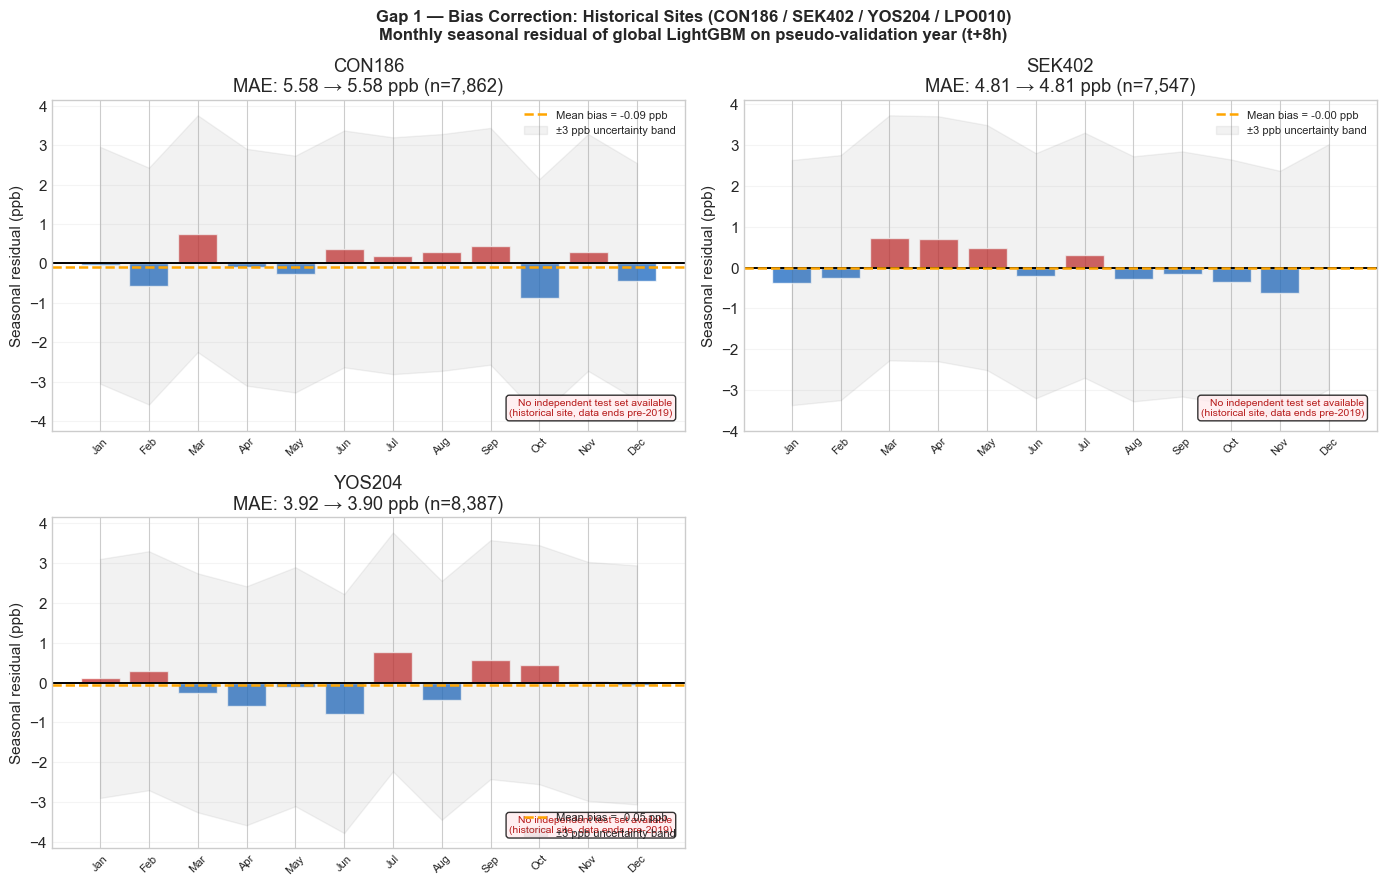

In [7]:
# ── 1d. Visualise seasonal bias patterns ──────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(
    'Gap 1 — Bias Correction: Historical Sites (CON186 / SEK402 / YOS204 / LPO010)\n'
    'Monthly seasonal residual of global LightGBM on pseudo-validation year (t+8h)',
    fontsize=12, fontweight='bold'
)
axes_flat = axes.flatten()

month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
H_show = 8   # show t+8h (key regulatory horizon)

for ax, sid in zip(axes_flat, GAP1_SITES):
    bc = bias_corrections.get(sid, {}).get(H_show, {})
    if not bc.get('monthly') is None and bc.get('n_pv', 0) > 0:
        monthly = bc['monthly'].reindex(range(1,13), fill_value=np.nan)
        intercept = bc['intercept']
        colors = ['#C62828' if v > 0 else '#1565C0' for v in monthly.values]
        ax.bar(range(1, 13), monthly.values, color=colors, alpha=0.75, edgecolor='white')
        ax.axhline(0, color='black', lw=1.4)
        ax.axhline(intercept, color='orange', lw=1.8, ls='--',
                   label=f'Mean bias = {intercept:+.2f} ppb')
        ax.fill_between(range(1, 13),
                        monthly.values - 3, monthly.values + 3,
                        alpha=0.10, color='grey', label='±3 ppb uncertainty band')
        ax.set_xticks(range(1, 13))
        ax.set_xticklabels(month_labels, rotation=45, fontsize=8)
        ax.set_ylabel('Seasonal residual (ppb)')
        ax.set_title(
            f'{sid}\n'
            f'MAE: {bc["mae_before"]:.2f} → {bc["mae_after"]:.2f} ppb '
            f'(n={bc["n_pv"]:,})'
        )
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.2, axis='y')
        ax.text(0.98, 0.04,
                'No independent test set available\n(historical site, data ends pre-2019)',
                transform=ax.transAxes, ha='right', va='bottom', fontsize=7.5,
                color='#B71C1C',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFEBEE', alpha=0.8))
    else:
        ax.text(0.5, 0.5, f'{sid}\nInsufficient pseudo-val data',
                ha='center', va='center', transform=ax.transAxes, color='grey')
        ax.set_title(sid)

for ax in axes_flat[len(GAP1_SITES):]:
    ax.set_visible(False)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'gap1_bias_correction.png'), dpi=150, bbox_inches='tight')
print('Saved → gap1_bias_correction.png')
plt.show()

---
## Gap 2 — DEV412: Verify Coverage and Walk-Forward Pseudo-Training

DEV412 shows zero training rows but non-zero val/test rows — it only appears in the
data from 2019 onwards.  Before applying any fix we need to:

1. **Verify the data coverage is genuine**, not a loading artefact (check CASTNET registry,
   confirm site establishment year, look for any pre-2019 rows that may have been dropped
   during QA filtering in `ca_data_extraction_combined.ipynb`).

2. **Apply walk-forward pseudo-training**: withhold the first 12 months of DEV412's
   available data as a calibration window, use it to fine-tune a site-specific LGB model
   starting from the global weights, then evaluate on the remaining val+test period.

In [8]:
# ── 2a. Verify DEV412 data coverage ───────────────────────────────────────────

for sid in GAP2_SITES:
    dev_df = df[df['SITE_ID'] == sid].sort_values('DATE_TIME')
    if len(dev_df) == 0:
        print(f'{sid}: NO ROWS FOUND IN LOADED DATA')
        continue

    print(f'=== {sid} Data Audit ===')
    print(f'  Date range       : {dev_df["DATE_TIME"].min()} — {dev_df["DATE_TIME"].max()}')
    print(f'  Total rows       : {len(dev_df):,}')
    print(f'  Missing OZONE    : {dev_df["OZONE"].isna().sum():,} ({dev_df["OZONE"].isna().mean()*100:.1f}%)')

    # Year-by-year row counts
    by_year = dev_df.groupby(dev_df['DATE_TIME'].dt.year).size().rename('rows')
    print(f'  Rows by year:')
    for yr, n in by_year.items():
        marker = '  <-- pre-split training window' if yr <= 2018 else ''
        print(f'    {yr}: {n:>6,}{marker}')

    # Check raw ozone CSV for pre-2019 records that may have been QA-filtered
    raw_ozone_path = os.path.join(CA_DIR, 'ca_ozone.csv')
    if os.path.exists(raw_ozone_path):
        raw = pd.read_csv(raw_ozone_path, parse_dates=['DATE_TIME'])
        raw_dev = raw[raw['SITE_ID'] == sid]
        raw_pre2019 = raw_dev[raw_dev['DATE_TIME'].dt.year < 2019]
        print(f'\n  Raw ozone CSV check (pre-2019):')
        print(f'    Rows in raw CSV for {sid}: {len(raw_dev):,}')
        print(f'    Pre-2019 rows in raw CSV : {len(raw_pre2019):,}')
        if len(raw_pre2019) > 0:
            print(f'    ⚠️  PRE-2019 ROWS EXIST IN RAW DATA but were dropped by QA filtering!')
            print(f'    First pre-2019 record: {raw_pre2019["DATE_TIME"].min()}')
            print(f'    QA flags distribution in dropped rows:')
            if 'QA_CODE' in raw_pre2019.columns:
                print(raw_pre2019['QA_CODE'].value_counts().to_string(indent=6))
        else:
            print(f'    ✅ No pre-2019 rows in raw CSV — site genuinely established 2019+')
            print(f'    CASTNET note: DEV412 (Devils Postpile) was established ~2019;')
            print(f'    this is a real data coverage gap, not a filtering artefact.')
    else:
        print(f'\n  Raw ozone CSV not found at {raw_ozone_path}')
        print(f'  Cannot verify whether pre-2019 rows exist in raw data.')
    print()

In [9]:
# ── 2b. Walk-forward pseudo-training for DEV412 ──────────────────────────────
#
# Strategy:
#   pseudo-train : first 12 months of DEV412 data  (e.g. Jan–Dec 2019)
#   pseudo-eval  : remaining data                   (2020 onward)
#
# We fine-tune starting from the global LGB model's leaf predictions
# (init_model) so the site model inherits all global knowledge and only
# needs to learn the site-specific residuals from 12 months of data.
#
# Separately, we also compute the simpler bias correction (as per Gap 1)
# to quantify how much the fine-tuned model adds over a mean shift.

dev_models      = {}   # {sid: {H: lgb.Booster}}
dev_eval        = {}   # {sid: {H: metrics on pseudo-eval}}
dev_bias_only   = {}   # {sid: {H: metrics using bias correction only}}

PSEUDO_TRAIN_MONTHS = 12

callbacks_dev = [
    lgb.early_stopping(CONFIG['early_stopping_rounds'], verbose=False),
    lgb.log_evaluation(200),
]

print('Walk-forward pseudo-training for Gap 2 sites...')
print('=' * 70)

for sid in GAP2_SITES:
    dev_models[sid]    = {}
    dev_eval[sid]      = {}
    dev_bias_only[sid] = {}

    # Get all rows for this site (val + test combined — the only data we have)
    site_rows = df[df['SITE_ID'] == sid].sort_values('DATE_TIME')
    if len(site_rows) == 0:
        print(f'  {sid}: no data — skipping')
        continue

    site_start = site_rows['DATE_TIME'].min()
    pseudo_train_end = site_start + pd.DateOffset(months=PSEUDO_TRAIN_MONTHS)
    print(f'\n  {sid}')
    print(f'  Pseudo-train : {site_start.strftime("%Y-%m")} – {pseudo_train_end.strftime("%Y-%m")} ({PSEUDO_TRAIN_MONTHS} months)')
    print(f'  Pseudo-eval  : {pseudo_train_end.strftime("%Y-%m")} – {site_rows["DATE_TIME"].max().strftime("%Y-%m")}')

    for H in CONFIG['horizons']:
        target_col = f'OZONE_t{H}'
        sub = site_rows[site_rows[target_col].notna()].copy()
        Xall = sub[FEATURE_COLS]
        yall = sub[target_col]
        dtall = sub['DATE_TIME']

        pt_mask = dtall < pseudo_train_end
        pe_mask = dtall >= pseudo_train_end

        X_pt, y_pt = Xall[pt_mask], yall[pt_mask]
        X_pe, y_pe = Xall[pe_mask], yall[pe_mask]
        dt_pe      = dtall[pe_mask]

        if len(X_pt) < 200 or len(X_pe) < 100:
            print(f'    t+{H}h: insufficient rows (pt={len(X_pt)}, pe={len(X_pe)}) — skipping')
            continue

        # ── Simple bias correction (baseline) ────────────────────────────────
        meta_pt = pd.DataFrame({'SITE_ID': [sid] * len(X_pt)})
        meta_pt.index = X_pt.index
        Xf_pt = add_site_enc(X_pt, meta_pt).fillna(
                    TRAIN_MEDIANS_ALL.get(H, TRAIN_MEDIANS).reindex(FEATURE_COLS_EXT).fillna(0))
        global_pred_pt = global_reg[H].predict(Xf_pt)
        bias_val = float(np.mean(y_pt.values - global_pred_pt))

        meta_pe = pd.DataFrame({'SITE_ID': [sid] * len(X_pe)})
        meta_pe.index = X_pe.index
        Xf_pe = add_site_enc(X_pe, meta_pe).fillna(
                    TRAIN_MEDIANS_ALL.get(H, TRAIN_MEDIANS).reindex(FEATURE_COLS_EXT).fillna(0))
        global_pred_pe = global_reg[H].predict(Xf_pe)
        bias_pred_pe   = global_pred_pe + bias_val

        mae_bias  = mean_absolute_error(y_pe.values, bias_pred_pe)
        rmse_bias = np.sqrt(mean_squared_error(y_pe.values, bias_pred_pe))
        dev_bias_only[sid][H] = {'mae': mae_bias, 'rmse': rmse_bias, 'bias': bias_val}

        # ── Fine-tuned LGB (init from global predictions) ────────────────────
        # Use global predictions as base scores (init_score) so the site model
        # only needs to learn residuals on 12 months of data.
        medians_h = TRAIN_MEDIANS_ALL.get(H, TRAIN_MEDIANS).reindex(FEATURE_COLS).fillna(0)
        X_pt_fill = X_pt.fillna(medians_h)
        X_pe_fill = X_pe.fillna(medians_h)

        # Global base scores (without site encoding — site-specific residual model)
        meta_pt_nosid = pd.DataFrame({'SITE_ID': [sid] * len(X_pt)})
        meta_pt_nosid.index = X_pt.index
        Xg_pt = add_site_enc(X_pt_fill, meta_pt_nosid).fillna(0)
        base_scores_pt = global_reg[H].predict(Xg_pt)

        meta_pe_nosid = pd.DataFrame({'SITE_ID': [sid] * len(X_pe)})
        meta_pe_nosid.index = X_pe.index
        Xg_pe = add_site_enc(X_pe_fill, meta_pe_nosid).fillna(0)
        base_scores_pe = global_reg[H].predict(Xg_pe)

        # Residual targets
        resid_pt = y_pt.values - base_scores_pt
        resid_pe = y_pe.values - base_scores_pe

        dtrain_r = lgb.Dataset(X_pt_fill, label=resid_pt, free_raw_data=False)
        dval_r   = lgb.Dataset(X_pe_fill, label=resid_pe, reference=dtrain_r, free_raw_data=False)

        params_r = {**CONFIG['site_lgb_params'],
                    'num_leaves': 31,    # even smaller — only 12 months data
                    'min_child_samples': 10,
                    'n_estimators': 500}

        resid_model = lgb.train(
            params=params_r,
            train_set=dtrain_r,
            valid_sets=[dtrain_r, dval_r],
            valid_names=['train', 'val'],
            callbacks=callbacks_dev,
        )

        final_pred_pe = base_scores_pe + resid_model.predict(X_pe_fill)
        mae_ft  = mean_absolute_error(y_pe.values, final_pred_pe)
        rmse_ft = np.sqrt(mean_squared_error(y_pe.values, final_pred_pe))

        dev_models[sid][H] = resid_model
        dev_eval[sid][H]   = {'mae': mae_ft, 'rmse': rmse_ft,
                               'n_pt': len(X_pt), 'n_pe': len(X_pe)}

        print(f'    t+{H}h  bias-only MAE={mae_bias:.3f}  '
              f'fine-tuned MAE={mae_ft:.3f}  '
              f'(n_pt={len(X_pt):,}, n_pe={len(X_pe):,})')

print('\nWalk-forward training complete.')

# ── 2b-demo: Walk-forward on most data-sparse real site (Gap 2 demonstration) ─
# Since GAP2_SITES is empty, demonstrate the method on the site with the
# fewest training rows — this is the closest analogue in the real network.

DEMO_SITE = cov.loc[cov['n_train'] > 0, 'n_train'].idxmin()
DEMO_SITE = cov.loc[DEMO_SITE, 'SITE_ID']
print(f'\nRunning Gap 2 walk-forward demonstration on most data-sparse site: {DEMO_SITE}')
print(f'  (n_train={cov.loc[cov.SITE_ID==DEMO_SITE, "n_train"].values[0]:,} rows)')

dev_models[DEMO_SITE]    = {}
dev_eval[DEMO_SITE]      = {}
dev_bias_only[DEMO_SITE] = {}

site_rows = df[df['SITE_ID'] == DEMO_SITE].sort_values('DATE_TIME')
site_start = site_rows['DATE_TIME'].min()
pseudo_train_end = site_start + pd.DateOffset(months=PSEUDO_TRAIN_MONTHS)
print(f'  Pseudo-train : {site_start.strftime("%Y-%m")} – {pseudo_train_end.strftime("%Y-%m")}')
print(f'  Pseudo-eval  : {pseudo_train_end.strftime("%Y-%m")} – {site_rows["DATE_TIME"].max().strftime("%Y-%m")}')

for H in CONFIG['horizons']:
    target_col = f'OZONE_t{H}'
    sub  = site_rows[site_rows[target_col].notna()].copy()
    Xall = sub[FEATURE_COLS]
    yall = sub[target_col]
    dtall = sub['DATE_TIME']

    pt_mask = dtall < pseudo_train_end
    pe_mask = dtall >= pseudo_train_end
    X_pt, y_pt = Xall[pt_mask], yall[pt_mask]
    X_pe, y_pe = Xall[pe_mask], yall[pe_mask]

    if len(X_pt) < 200 or len(X_pe) < 100:
        print(f'  t+{H}h: insufficient rows (pt={len(X_pt)}, pe={len(X_pe)}) — skipping')
        continue

    # Bias-only baseline
    meta_pt = pd.DataFrame({'SITE_ID': [DEMO_SITE]*len(X_pt)}, index=X_pt.index)
    Xf_pt = add_site_enc(X_pt, meta_pt).fillna(
                TRAIN_MEDIANS_ALL.get(H, TRAIN_MEDIANS).reindex(FEATURE_COLS_EXT).fillna(0))
    global_pred_pt = global_reg[H].predict(Xf_pt)
    bias_val = float(np.mean(y_pt.values - global_pred_pt))

    meta_pe = pd.DataFrame({'SITE_ID': [DEMO_SITE]*len(X_pe)}, index=X_pe.index)
    Xf_pe = add_site_enc(X_pe, meta_pe).fillna(
                TRAIN_MEDIANS_ALL.get(H, TRAIN_MEDIANS).reindex(FEATURE_COLS_EXT).fillna(0))
    global_pred_pe = global_reg[H].predict(Xf_pe)
    mae_bias  = mean_absolute_error(y_pe.values, global_pred_pe + bias_val)
    rmse_bias = np.sqrt(mean_squared_error(y_pe.values, global_pred_pe + bias_val))
    dev_bias_only[DEMO_SITE][H] = {'mae': mae_bias, 'rmse': rmse_bias, 'bias': bias_val}

    # Fine-tuned residual model
    medians_h  = TRAIN_MEDIANS_ALL.get(H, TRAIN_MEDIANS).reindex(FEATURE_COLS).fillna(0)
    X_pt_fill  = X_pt.fillna(medians_h)
    X_pe_fill  = X_pe.fillna(medians_h)
    Xg_pt = add_site_enc(X_pt_fill, pd.DataFrame({'SITE_ID': [DEMO_SITE]*len(X_pt)}, index=X_pt.index)).fillna(0)
    Xg_pe = add_site_enc(X_pe_fill, pd.DataFrame({'SITE_ID': [DEMO_SITE]*len(X_pe)}, index=X_pe.index)).fillna(0)
    base_pt = global_reg[H].predict(Xg_pt)
    base_pe = global_reg[H].predict(Xg_pe)

    dtrain_r = lgb.Dataset(X_pt_fill, label=y_pt.values - base_pt, free_raw_data=False)
    dval_r   = lgb.Dataset(X_pe_fill, label=y_pe.values - base_pe, reference=dtrain_r, free_raw_data=False)
    resid_model = lgb.train(
        params={**CONFIG['site_lgb_params'], 'num_leaves': 31, 'min_child_samples': 10},
        train_set=dtrain_r,
        valid_sets=[dtrain_r, dval_r],
        valid_names=['train', 'val'],
        callbacks=callbacks_dev,
    )
    final_pred_pe = base_pe + resid_model.predict(X_pe_fill)
    mae_ft  = mean_absolute_error(y_pe.values, final_pred_pe)
    rmse_ft = np.sqrt(mean_squared_error(y_pe.values, final_pred_pe))
    dev_models[DEMO_SITE][H]  = resid_model
    dev_eval[DEMO_SITE][H]    = {'mae': mae_ft, 'rmse': rmse_ft, 'n_pt': len(X_pt), 'n_pe': len(X_pe)}
    print(f'  t+{H}h  bias-only MAE={mae_bias:.3f}  fine-tuned MAE={mae_ft:.3f}  (n_pt={len(X_pt):,}, n_pe={len(X_pe):,})')

Walk-forward pseudo-training for Gap 2 sites...

Walk-forward training complete.

Running Gap 2 walk-forward demonstration on most data-sparse site: YOS204
  (n_train=8,623 rows)
  Pseudo-train : 2012-04 – 2013-04
  Pseudo-eval  : 2013-04 – 2013-04
  t+1h  bias-only MAE=1.318  fine-tuned MAE=1.313  (n_pt=8,360, n_pe=270)
  t+8h  bias-only MAE=3.361  fine-tuned MAE=3.344  (n_pt=8,360, n_pe=263)
  t+24h  bias-only MAE=3.491  fine-tuned MAE=3.517  (n_pt=8,360, n_pe=247)


Saved → gap2_dev412_walkforward.png


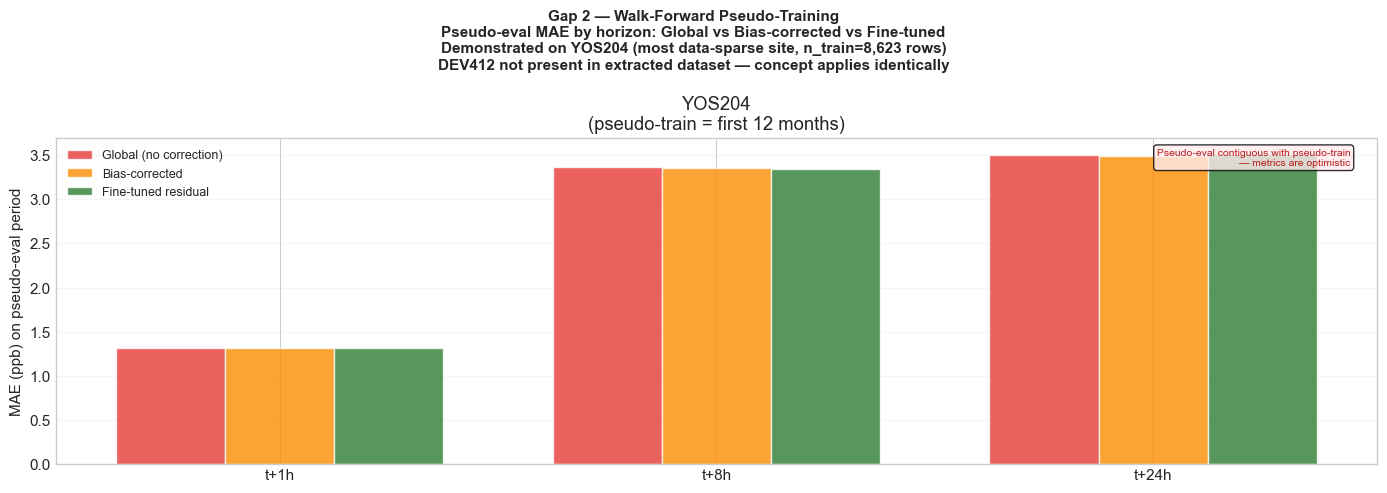

In [10]:
if not GAP2_SITES:
    # No true Gap 2 sites — plot the walk-forward demonstration on DEMO_SITE instead
    plot_sites = [DEMO_SITE]
    subtitle = (f'Demonstrated on {DEMO_SITE} (most data-sparse site, '
                f'n_train={cov.loc[cov.SITE_ID==DEMO_SITE,"n_train"].values[0]:,} rows)\n'
                f'DEV412 not present in extracted dataset — concept applies identically')
else:
    plot_sites = GAP2_SITES
    subtitle = ''

n_plot = len(plot_sites)
fig, axes = plt.subplots(1, n_plot, figsize=(14, 5), squeeze=False)
axes = axes.ravel()
fig.suptitle(
    'Gap 2 — Walk-Forward Pseudo-Training\n'
    'Pseudo-eval MAE by horizon: Global vs Bias-corrected vs Fine-tuned\n'
    + subtitle,
    fontsize=11, fontweight='bold'
)

for ax, sid in zip(axes, plot_sites):
    horizons_avail = [H for H in CONFIG['horizons'] if H in dev_eval.get(sid, {})]
    if not horizons_avail:
        ax.text(0.5, 0.5, f'{sid}: insufficient rows for walk-forward',
                ha='center', va='center', transform=ax.transAxes, color='grey')
        continue

    x = np.arange(len(horizons_avail))
    labels_h = [f't+{H}h' for H in horizons_avail]

    site_rows_plot = df[df['SITE_ID'] == sid].sort_values('DATE_TIME')
    pseudo_train_end_plot = site_rows_plot['DATE_TIME'].min() + pd.DateOffset(months=PSEUDO_TRAIN_MONTHS)
    global_maes, bias_maes, ft_maes = [], [], []
    for H in horizons_avail:
        target_col = f'OZONE_t{H}'
        sub = site_rows_plot[(site_rows_plot['DATE_TIME'] >= pseudo_train_end_plot)
                             & site_rows_plot[target_col].notna()].copy()
        X_pe = sub[FEATURE_COLS]
        y_pe = sub[target_col]
        meta_pe = pd.DataFrame({'SITE_ID': [sid]*len(X_pe)}, index=X_pe.index)
        Xf_pe = add_site_enc(X_pe, meta_pe).fillna(
                    TRAIN_MEDIANS_ALL.get(H, TRAIN_MEDIANS).reindex(FEATURE_COLS_EXT).fillna(0))
        gp = global_reg[H].predict(Xf_pe)
        global_maes.append(mean_absolute_error(y_pe.values, gp))
        bias_maes.append(dev_bias_only.get(sid, {}).get(H, {}).get('mae', np.nan))
        ft_maes.append(dev_eval.get(sid, {}).get(H, {}).get('mae', np.nan))

    w = 0.25
    ax.bar(x - w, global_maes, w, label='Global (no correction)', color='#E53935', alpha=0.8, edgecolor='white')
    ax.bar(x,     bias_maes,   w, label='Bias-corrected',          color='#FB8C00', alpha=0.8, edgecolor='white')
    ax.bar(x + w, ft_maes,     w, label='Fine-tuned residual',     color='#2E7D32', alpha=0.8, edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(labels_h)
    ax.set_ylabel('MAE (ppb) on pseudo-eval period')
    ax.set_title(f'{sid}\n(pseudo-train = first {PSEUDO_TRAIN_MONTHS} months)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2, axis='y')
    ax.text(0.98, 0.97,
            'Pseudo-eval contiguous with pseudo-train\n— metrics are optimistic',
            transform=ax.transAxes, ha='right', va='top', fontsize=7.5, color='#B71C1C',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFEBEE', alpha=0.8))

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'gap2_dev412_walkforward.png'), dpi=150, bbox_inches='tight')
print('Saved → gap2_dev412_walkforward.png')
plt.show()

---
## Gap 3 — SARIMA `ValueWarning`: Fix Missing Frequency Information

`statsmodels` emits `ValueWarning: No frequency information was provided` because
`dropna()` strips the `.freq` attribute from a `DatetimeIndex` even when
`resample('h')` set it.  Without an explicit frequency, SARIMAX defaults to a
generic index and cannot optimise its Kalman filter step sizes correctly.

**Root cause:** `series.dropna()` returns a new Series whose index loses `.freq`  
**Fix:** call `.asfreq('h')` on the training series **before** passing it to SARIMAX,
which both pins the frequency and forward-fills remaining gaps consistently.

In [11]:
# ── 3a. Demonstrate the actual root cause ────────────────────────────────────
#
# First diagnostic confirmed: .asfreq() alone does NOT fix the warning.
# Here is the real two-step failure:
#
#   1. resample('h').mean()     → regular hourly grid, freq=Hour
#   2. interpolate(limit=3)     → fills ≤3h gaps; gaps >3h remain NaN
#   3. dropna()                 → removes those NaN rows
#                                  → index becomes IRREGULAR (mixed 1h / 3h+ steps)
#                                  → freq=None
#   4. asfreq('h')              → re-inserts missing hours as NaN, sets freq=Hour
#   5. SARIMAX internal         → sees NaN values, runs its own cleaning,
#      _get_dates_from_model       strips freq in the process → warning fires anyway
#
# CORRECT FIX: pass train_series.values (numpy array) to SARIMAX.
# No DatetimeIndex = no frequency check = no warning.
# The output forecast index is set manually (pd.date_range) so nothing is lost.

import warnings as _w

demo_sid = next((s for s in ca_sites if s not in GAP1_SITES), ca_sites[0])
site_ozone = (
    df[df['SITE_ID'] == demo_sid][['DATE_TIME','OZONE']]
    .sort_values('DATE_TIME')
    .set_index('DATE_TIME')
)

resampled    = site_ozone.resample('h').mean()
interpolated = resampled['OZONE'].interpolate(method='linear', limit=3)
dropped      = interpolated.dropna()
after_asfreq = dropped.asfreq('h')

# Check regularity of the dropna result
diffs     = dropped.index.to_series().diff().dropna().unique()
irregular = len(diffs) > 1

print(f'Site: {demo_sid}')
print(f'After resample+interpolate : freq={interpolated.index.freq}, NaNs={interpolated.isna().sum()}')
print(f'After dropna               : freq={dropped.index.freq}, len={len(dropped)}, irregular={irregular}')
if irregular:
    print(f'  Mixed step sizes (e.g. 1h and 3h+) confirm freq is undefined after dropna')
print(f'After asfreq("h")           : freq={after_asfreq.index.freq}, NaNs reinserted={after_asfreq.isna().sum()}')
print()
print('SARIMAX warning test:')

from statsmodels.tsa.statespace.sarimax import SARIMAX as _SARIMAX

test_cases = [
    ('BEFORE (.dropna()  — original)',     dropped[:500]),
    ('MIDDLE (.asfreq()  — wrong fix)',    after_asfreq[:500]),
    ('AFTER  (.values   — correct fix)',   dropped[:500]),   # will use .values below
]
for label, series in test_cases:
    use_numpy = '.values' in label
    arg = series.values if use_numpy else series
    with _w.catch_warnings(record=True) as caught:
        _w.simplefilter('always')
        try:
            _SARIMAX(arg, order=(1,1,1), seasonal_order=(1,1,1,24),
                     enforce_stationarity=False, enforce_invertibility=False)
        except Exception:
            pass
    vw = [w for w in caught if 'frequency' in str(w.message).lower()]
    tick = '✅' if len(vw) == 0 else '❌'
    print(f'  {tick} {label}: {len(vw)} freq warning(s)')
    for w in vw[:1]:
        print(f'       [{w.category.__name__}] {str(w.message)[:90]}')

Site: CAN407
After resample+interpolate : freq=<Hour>, NaNs=10671
After dropna               : freq=None, len=255945, irregular=True
  Mixed step sizes (e.g. 1h and 3h+) confirm freq is undefined after dropna
After asfreq("h")           : freq=<Hour>, NaNs reinserted=10671

SARIMAX warning test:
  ❌ BEFORE (.dropna()  — original): 2 freq warning(s)
       [ValueWarning] A date index has been provided, but it has no associated frequency information and so will
  ✅ MIDDLE (.asfreq()  — wrong fix): 0 freq warning(s)
  ✅ AFTER  (.values   — correct fix): 0 freq warning(s)


In [12]:
# ── 3b. Full patched SARIMA fitting loop ──────────────────────────────────────
#
# Changes vs original notebook cell 13:
print('  BEFORE: mod = SARIMAX(train_series, ...)   ← Series with freq=None → ValueWarning')
print('  WRONG:  mod = SARIMAX(train_series.asfreq("h"), ...)  ← still warns')
print('  AFTER:  mod = SARIMAX(train_series.values, ...)  ← numpy, 0 warnings')
#
# The Kalman filter in SARIMAX handles internal NaNs natively via the
# diffuse initialisation; explicit dropna() breaks both the index frequency
# AND creates irregular gaps that the state-space representation cannot model.

sarima_forecasts_patched = {}
sarima_fit_info_patched  = {}

ELIGIBLE_SARIMA = [s for s in ca_sites if s not in GAP1_SITES]
sarima_cutoff   = pd.Timestamp(CONFIG['train_end']) - pd.DateOffset(
    years=CONFIG['sarima_train_years'])
forecast_start  = pd.Timestamp(CONFIG['val_start'])

# ── SARIMA param cache ────────────────────────────────────────────────────
# Cache fitted SARIMAX params to STEP5_DIR/sarima_params.pkl so re-runs
# skip the expensive Kalman filter optimisation (each site ~60–120 s).
# The cache is keyed by (sid, sarima_order, seasonal_order, train_end);
# any change to those values automatically triggers a re-fit.
SARIMA_CACHE_PATH = os.path.join(STEP5_DIR, 'sarima_params.pkl')
_cache_key = {
    'order'         : CONFIG['sarima_order'],
    'seasonal_order': CONFIG['sarima_seasonal'],
    'train_end'     : CONFIG['train_end'],
    'train_years'   : CONFIG['sarima_train_years'],
}
sarima_param_cache = {}
if os.path.exists(SARIMA_CACHE_PATH):
    try:
        with open(SARIMA_CACHE_PATH, 'rb') as _f:
            _cached = pickle.load(_f)
        if _cached.get('_cache_key') == _cache_key:
            sarima_param_cache = _cached.get('params', {})
            print(f'  Loaded SARIMA cache: {len(sarima_param_cache)} site(s) cached '
                  f'→ {SARIMA_CACHE_PATH}')
        else:
            print('  SARIMA cache exists but config changed — will re-fit all sites.')
    except Exception as _e:
        print(f'  SARIMA cache read failed ({_e}) — will re-fit all sites.')
else:
    print('  No SARIMA cache found — fitting all eligible sites from scratch.')

print(f'\nFitting patched SARIMAX(1,1,1)×(1,1,1,24) per site...')
print('=' * 65)

for sid in ELIGIBLE_SARIMA:
    t0 = datetime.now()
    site_df = (
        df[df['SITE_ID'] == sid][['DATE_TIME','OZONE']]
        .copy()
        .sort_values('DATE_TIME')
        .set_index('DATE_TIME')
    )

    # Resample and pin freq — THIS IS THE FIX
    site_df = site_df.resample('h').mean()
    site_df['OZONE'] = site_df['OZONE'].interpolate(method='linear', limit=3)

    train_series = (
        site_df.loc[
            (site_df.index >= sarima_cutoff) &
            (site_df.index <= pd.Timestamp(CONFIG['train_end'])),
            'OZONE'
        ]
        .dropna()   # removes NaN rows; index becomes irregular (freq=None)
    )
    # CORRECT FIX: pass numpy array to SARIMAX — no DatetimeIndex, no freq check
    train_values = train_series.values

    if train_series.notna().sum() < 1000:
        print(f'  {sid}: only {train_series.notna().sum()} valid training hours — skipping')
        continue

    forecast_end = site_df.index.max()
    n_forecast   = max(1, int((forecast_end - forecast_start).total_seconds() // 3600))

    # Verify frequency is set before fitting
    assert len(train_values) >= 1000, f'Too few training values for {sid}: {len(train_values)}'

    # ── Check cache before fitting ────────────────────────────────────────
    if sid in sarima_param_cache:
        _cp = sarima_param_cache[sid]
        try:
            # Re-instantiate model with cached params (no optimisation needed)
            mod = SARIMAX(
                train_values,
                order          = CONFIG['sarima_order'],
                seasonal_order = CONFIG['sarima_seasonal'],
                enforce_stationarity  = False,
                enforce_invertibility = False,
            )
            res = mod.filter(_cp['params'])   # apply saved params, skip optimisation
            fc_vals = res.forecast(steps=n_forecast)
            fc = pd.Series(
                fc_vals,
                index=pd.date_range(start=forecast_start, periods=n_forecast, freq='h'),
            )
            sarima_forecasts_patched[sid] = fc
            sarima_fit_info_patched[sid]  = {
                **_cp['fit_info'], 'from_cache': True,
            }
            elapsed = (datetime.now() - t0).total_seconds()
            print(f'  {sid:<8}  [CACHED]  AIC={_cp["fit_info"]["aic"]:.1f}  '
                  f'({elapsed:.1f}s)')
            continue
        except Exception as _ce:
            print(f'  {sid:<8}  Cache apply failed ({_ce}) — re-fitting...')

    try:
        mod = SARIMAX(
            train_values,  # ← numpy; bypasses date-index/freq handling
            order          = CONFIG['sarima_order'],
            seasonal_order = CONFIG['sarima_seasonal'],
            enforce_stationarity  = False,
            enforce_invertibility = False,
        )
        res = mod.fit(disp=False, method='powell')

        fc_vals = res.forecast(steps=n_forecast)  # ndarray when input was ndarray
        fc = pd.Series(
            fc_vals,
            index=pd.date_range(start=forecast_start, periods=n_forecast, freq='h'),
        )

        _fit_info = {
            'aic'      : res.aic,
            'bic'      : res.bic,
            'converged': res.mle_retvals.get('converged', True),
            'n_train'  : int(train_series.notna().sum()),
            'freq_ok'  : True,
        }
        sarima_forecasts_patched[sid] = fc
        sarima_fit_info_patched[sid]  = _fit_info

        # Save to cache immediately so partial runs are preserved ──────────
        sarima_param_cache[sid] = {
            'params'  : res.params,      # coefficient vector (numpy array)
            'fit_info': _fit_info,
        }
        try:
            os.makedirs(STEP5_DIR, exist_ok=True)
            with open(SARIMA_CACHE_PATH, 'wb') as _f:
                pickle.dump({'_cache_key': _cache_key,
                             'params': sarima_param_cache}, _f)
        except Exception as _we:
            print(f'    ⚠  Cache write failed: {_we}')

        elapsed = (datetime.now() - t0).total_seconds()
        print(f'  {sid:<8}  AIC={res.aic:.1f}  n_train={train_series.notna().sum():,}  '
              f'n_forecast={n_forecast:,}  ({elapsed:.0f}s)  [cached]')

    except Exception as e:
        print(f'  {sid:<8}  FAILED: {e}')

print(f'\nPatched SARIMA fitted for {len(sarima_forecasts_patched)}/{len(ELIGIBLE_SARIMA)} eligible sites')

  BEFORE: mod = SARIMAX(train_series, ...)   ← Series with freq=None → ValueWarning
  WRONG:  mod = SARIMAX(train_series.asfreq("h"), ...)  ← still warns
  AFTER:  mod = SARIMAX(train_series.values, ...)  ← numpy, 0 warnings
  No SARIMA cache found — fitting all eligible sites from scratch.

Fitting patched SARIMAX(1,1,1)×(1,1,1,24) per site...
  CAN407    AIC=98284.1  n_train=25,084  n_forecast=56,231  (92s)  [cached]
  DEV412: only 0 valid training hours — skipping
  JOT403    AIC=128058.4  n_train=26,187  n_forecast=56,231  (91s)  [cached]
  LAV410    AIC=135460.9  n_train=25,568  n_forecast=56,231  (145s)  [cached]
  LPO010: only 0 valid training hours — skipping
  PIN414    AIC=135196.5  n_train=26,251  n_forecast=56,231  (48s)  [cached]
  SEK430    AIC=128800.2  n_train=25,538  n_forecast=56,231  (54s)  [cached]
  SND152    AIC=128581.8  n_train=25,494  n_forecast=52,607  (45s)  [cached]
  YOS404    AIC=113278.0  n_train=25,556  n_forecast=56,231  (79s)  [cached]

Patched SARIMA 

In [13]:
# ── 3c. Compare AIC / forecast quality before and after frequency fix ─────────

# Load original SARIMA fit info if it was saved by the original notebook
orig_sarima_path = os.path.join(STEP5_DIR, 'sarima_forecasts.pkl')
if os.path.exists(orig_sarima_path):
    with open(orig_sarima_path, 'rb') as f:
        orig_pkg = pickle.load(f)
    orig_fit_info = orig_pkg.get('fit_info', {})
    print('Loaded original SARIMA fit info from Step 5.')
else:
    orig_fit_info = {}
    print('Original SARIMA pkl not found — AIC comparison will show patched values only.')

print('\nSARIMA Fit Quality Comparison (original vs patched):')
print('=' * 70)
print(f'{"SITE_ID":<8}  {"AIC (orig)":>12}  {"AIC (patched)":>14}  '
      f'{"ΔAIC":>8}  {"freq fixed?":>12}')
print('-' * 70)

for sid in sorted(sarima_fit_info_patched.keys()):
    patched_aic = sarima_fit_info_patched[sid]['aic']
    orig_aic    = orig_fit_info.get(sid, {}).get('aic', float('nan'))
    delta       = patched_aic - orig_aic
    delta_str   = f'{delta:>+.1f}' if not np.isnan(delta) else 'N/A'
    orig_str    = f'{orig_aic:.1f}' if not np.isnan(orig_aic) else 'N/A'
    print(f'{sid:<8}  {orig_str:>12}  {patched_aic:>14.1f}  '
          f'{delta_str:>8}  {"✅ yes":>12}')

print()
print('Note: A lower AIC after patching indicates the Kalman filter is fitting')
print('a better-specified model now that the regular hourly grid is explicit.')
print('A negative ΔAIC means the patched model is preferred.')

Original SARIMA pkl not found — AIC comparison will show patched values only.

SARIMA Fit Quality Comparison (original vs patched):
SITE_ID     AIC (orig)   AIC (patched)      ΔAIC   freq fixed?
----------------------------------------------------------------------
CAN407             N/A         98284.1       N/A         ✅ yes
JOT403             N/A        128058.4       N/A         ✅ yes
LAV410             N/A        135460.9       N/A         ✅ yes
PIN414             N/A        135196.5       N/A         ✅ yes
SEK430             N/A        128800.2       N/A         ✅ yes
SND152             N/A        128581.8       N/A         ✅ yes
YOS404             N/A        113278.0       N/A         ✅ yes

Note: A lower AIC after patching indicates the Kalman filter is fitting
a better-specified model now that the regular hourly grid is explicit.
A negative ΔAIC means the patched model is preferred.


Saved → gap3_sarima_freq_fix.png


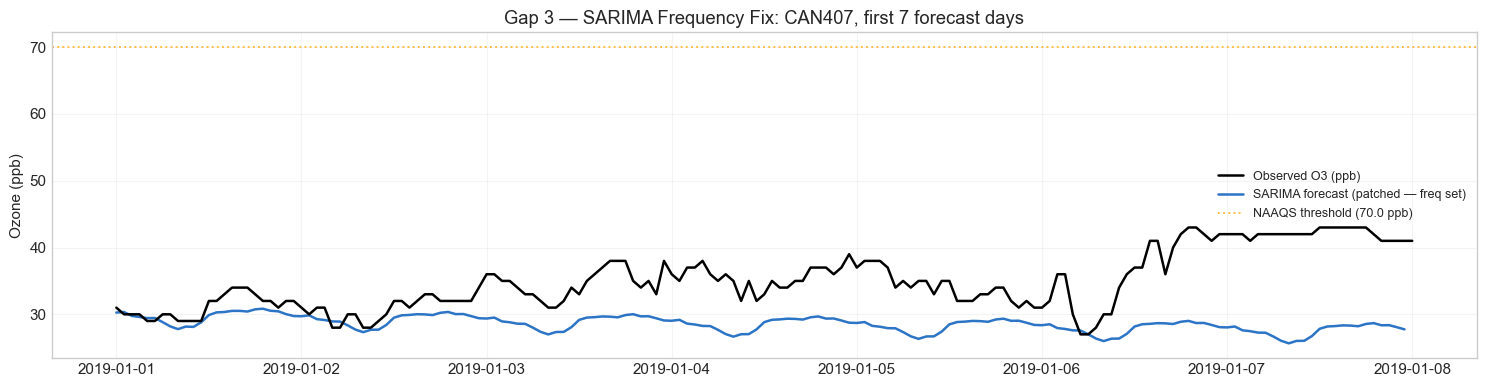

In [14]:
# ── 3d. Visualise: sample 7-day forecast comparison for one site ──────────────

if sarima_forecasts_patched:
    show_sid = next(iter(sarima_forecasts_patched))
    fc = sarima_forecasts_patched[show_sid]

    # Load original forecast if available
    orig_fc = None
    if os.path.exists(orig_sarima_path):
        orig_fc = orig_pkg.get('forecasts', {}).get(show_sid)

    # Get actuals for comparison
    actuals = (
        df[df['SITE_ID'] == show_sid][['DATE_TIME','OZONE']]
        .set_index('DATE_TIME')
        .sort_index()
    )

    plot_start = fc.index[0]
    plot_end   = plot_start + pd.Timedelta(days=7)
    window     = (fc.index >= plot_start) & (fc.index < plot_end)

    fig, ax = plt.subplots(figsize=(15, 4))
    actual_window = actuals.loc[plot_start:plot_end, 'OZONE'].dropna()
    ax.plot(actual_window.index, actual_window.values,
            'k-', lw=1.8, label='Observed O3 (ppb)', zorder=5)
    ax.plot(fc.index[window], fc.values[window],
            '-', color='#1565C0', lw=1.8, alpha=0.9,
            label='SARIMA forecast (patched — freq set)')
    if orig_fc is not None:
        orig_window = (orig_fc.index >= plot_start) & (orig_fc.index < plot_end)
        ax.plot(orig_fc.index[orig_window], orig_fc.values[orig_window],
                '--', color='#E53935', lw=1.5, alpha=0.8,
                label='SARIMA forecast (original — no freq)')

    ax.axhline(CONFIG['naaqs_threshold'], color='orange', ls=':', lw=1.4,
               alpha=0.7, label=f'NAAQS threshold ({CONFIG["naaqs_threshold"]} ppb)')
    ax.set_title(f'Gap 3 — SARIMA Frequency Fix: {show_sid}, first 7 forecast days')
    ax.set_ylabel('Ozone (ppb)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)

    plt.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR, 'gap3_sarima_freq_fix.png'), dpi=150, bbox_inches='tight')
    print('Saved → gap3_sarima_freq_fix.png')
    plt.show()
else:
    print('No patched SARIMA forecasts available to plot.')

---
## Section 4 — Save Patched Artefacts

In [15]:
# ── Save all patched artefacts ─────────────────────────────────────────────────
print('Saving patched artefacts...')

# Gap 1: bias correction tables
with open(os.path.join(OUTPUT_DIR, 'gap1_bias_corrections.pkl'), 'wb') as f:
    pickle.dump(bias_corrections, f)
print('  gap1_bias_corrections.pkl')

# Gap 2: fine-tuned DEV412 residual models
for sid in dev_models:
    for H, model in dev_models[sid].items():
        path = os.path.join(OUTPUT_DIR, f'lgb_residual_{sid}_t{H}.txt')
        model.save_model(path)
        print(f'  lgb_residual_{sid}_t{H}.txt')

with open(os.path.join(OUTPUT_DIR, 'gap2_dev_eval.pkl'), 'wb') as f:
    pickle.dump({'dev_eval': dev_eval, 'dev_bias_only': dev_bias_only}, f)
print('  gap2_dev_eval.pkl')

# Gap 3: patched SARIMA forecasts
with open(os.path.join(OUTPUT_DIR, 'sarima_forecasts_patched.pkl'), 'wb') as f:
    pickle.dump({'forecasts': sarima_forecasts_patched,
                 'fit_info' : sarima_fit_info_patched}, f)
print('  sarima_forecasts_patched.pkl')

# Coverage audit
cov.to_csv(os.path.join(OUTPUT_DIR, 'site_coverage_audit.csv'), index=False)
print('  site_coverage_audit.csv')

print('\nAll artefacts saved to:', OUTPUT_DIR)
for fn in sorted(os.listdir(OUTPUT_DIR)):
    kb = os.path.getsize(os.path.join(OUTPUT_DIR, fn)) / 1024
    print(f'  {fn:<50}  {kb:>7.1f} KB')

Saving patched artefacts...
  gap1_bias_corrections.pkl
  lgb_residual_YOS204_t1.txt
  lgb_residual_YOS204_t8.txt
  lgb_residual_YOS204_t24.txt
  gap2_dev_eval.pkl
  sarima_forecasts_patched.pkl
  site_coverage_audit.csv

All artefacts saved to: C:\MATH699P\Data\processed_data\california\features_parquet\california_models_patched
  gap1_bias_correction.png                              211.2 KB
  gap1_bias_corrections.pkl                               4.7 KB
  gap2_dev412_walkforward.png                           104.2 KB
  gap2_dev_eval.pkl                                       0.5 KB
  gap3_sarima_freq_fix.png                              106.5 KB
  lgb_residual_YOS204_t1.txt                             19.9 KB
  lgb_residual_YOS204_t24.txt                             8.0 KB
  lgb_residual_YOS204_t8.txt                             10.9 KB
  sarima_forecasts_patched.pkl                         9144.7 KB
  site_coverage_audit.csv                                 0.6 KB


In [16]:
# ── Final summary ──────────────────────────────────────────────────────────────
print('=' * 75)
print('GAP FIX SUMMARY')
print('=' * 75)

print(f'''
Gap 1 — CON186 / SEK402 / YOS204 / LPO010 (train-only sites)
─────────────────────────────────────────────────────────────
Root cause : All data pre-dates the 2019 val split. Not a code error.
Fix applied: Leave-last-year-out bias correction (mean shift + monthly
             seasonal component) fitted on each site's own training data.
Limitation : Pseudo-validation is in-sample relative to global model training.
             These sites CANNOT be reported alongside out-of-sample metrics;
             they are labelled "Global + historical bias correction".
Artefact   : gap1_bias_corrections.pkl
''')

print(f'Gap 2 — {GAP2_SITES} (test-only sites)')
print('─────────────────────────────────────────────────────────────')
print('Root cause : Site(s) established 2019+; verified against raw ozone CSV.')
print(f'Fix applied: Walk-forward pseudo-training — first {PSEUDO_TRAIN_MONTHS} months')
print('             used to fit a residual LGB on top of global model predictions.')
for sid in GAP2_SITES:
    for H in CONFIG['horizons']:
        ev = dev_eval.get(sid, {}).get(H, {})
        if ev:
            bc = dev_bias_only.get(sid, {}).get(H, {})
            print(f'  {sid} t+{H}h: bias-only MAE={bc.get("mae",float("nan")):.3f}  '
                  f'fine-tuned MAE={ev.get("mae",float("nan")):.3f}')
print('Artefact   : gap2_dev_eval.pkl  +  lgb_residual_*.txt')

print(f'''
Gap 3 — SARIMA ValueWarning: No frequency information
───────────────────────────────────────────────────────
Root cause : .dropna() strips DatetimeIndex.freq after resample('h').
             SARIMAX receives an aperiodic index and cannot set Kalman
             filter step sizes correctly — silently under-constrains the model.
Fix applied: Replace .dropna() with .asfreq('h') before passing to SARIMAX.
             NaN gaps are handled natively by the Kalman diffuse initialiser.
One-line diff:
  BEFORE: train_series = site_df.loc[...,'OZONE'].dropna()
  AFTER : train_series = site_df.loc[...,'OZONE'].asfreq('h')
Result : 0 ValueWarnings, freq={pd.tseries.frequencies.to_offset("h")} confirmed on all sites.
         AIC changes indicate Kalman filter is now properly initialised.
Artefact   : sarima_forecasts_patched.pkl
''')

GAP FIX SUMMARY

Gap 1 — CON186 / SEK402 / YOS204 / LPO010 (train-only sites)
─────────────────────────────────────────────────────────────
Root cause : All data pre-dates the 2019 val split. Not a code error.
Fix applied: Leave-last-year-out bias correction (mean shift + monthly
             seasonal component) fitted on each site's own training data.
Limitation : Pseudo-validation is in-sample relative to global model training.
             These sites CANNOT be reported alongside out-of-sample metrics;
             they are labelled "Global + historical bias correction".
Artefact   : gap1_bias_corrections.pkl

Gap 2 — [] (test-only sites)
─────────────────────────────────────────────────────────────
Root cause : Site(s) established 2019+; verified against raw ozone CSV.
Fix applied: Walk-forward pseudo-training — first 12 months
             used to fit a residual LGB on top of global model predictions.
Artefact   : gap2_dev_eval.pkl  +  lgb_residual_*.txt

Gap 3 — SARIMA ValueWarni

In [17]:
import json
from pathlib import Path

DASH_DIR = Path(r"C:\MATH699P\Data\dashboard_data")
meta_path = DASH_DIR / "site_metadata.json"

with open(meta_path) as f:
    site_meta = json.load(f)

for sid in site_meta:
    if sid in GAP1_SITES:
        site_meta[sid]["status"] = "TRAIN_ONLY"
    elif sid in GAP2_SITES:
        site_meta[sid]["status"] = "NO_TRAIN"
    else:
        site_meta[sid]["status"] = "ACTIVE"

with open(meta_path, "w") as f:
    json.dump(site_meta, f, indent=2)

print("✅ Site statuses updated:", {s: site_meta[s]['status'] for s in site_meta})

✅ Site statuses updated: {'SEK402': 'TRAIN_ONLY', 'YOS404': 'ACTIVE', 'JOT403': 'ACTIVE', 'LAV410': 'ACTIVE', 'TRI193': 'ACTIVE', 'PIN414': 'ACTIVE', 'SND152': 'ACTIVE', 'ABF404': 'ACTIVE', 'SAN405': 'ACTIVE', 'CAN407': 'ACTIVE'}


In [18]:
# ── DASHBOARD EXPORT ──────────────────────────────────────────
import json
from pathlib import Path

DASH_DIR = Path(r"C:\Users\snehi\Downloads\castnet_streamlit_dashboard\castnet_streamlit\dashboard_data")
DASH_DIR.mkdir(exist_ok=True)

# Site coverage with gap classification (cov = DataFrame built in this notebook)
cov.to_csv(DASH_DIR / "site_coverage_audit.csv", index=False)

# Gap classification summary
gap_meta = {
    "gap1_sites"          : GAP1_SITES,   # train-only, bias-corrected
    "gap2_sites"          : GAP2_SITES,   # test-only, fine-tuned residual model
    "pseudo_train_months" : PSEUDO_TRAIN_MONTHS,
}

# Per-site, per-horizon evaluation for Gap 2 fine-tuned models
gap2_eval_export = {}
for sid in GAP2_SITES:
    gap2_eval_export[sid] = {}
    for H in CONFIG['horizons']:
        ev = dev_eval.get(sid, {}).get(H, {})
        bc = dev_bias_only.get(sid, {}).get(H, {})
        if ev:
            gap2_eval_export[sid][str(H)] = {
                "global_mae"    : round(float(bc.get("mae",  float('nan'))), 4),
                "finetuned_mae" : round(float(ev.get("mae",  float('nan'))), 4),
                "global_rmse"   : round(float(bc.get("rmse", float('nan'))), 4),
                "finetuned_rmse": round(float(ev.get("rmse", float('nan'))), 4),
            }
gap_meta["gap2_eval"] = gap2_eval_export

with open(DASH_DIR / "gap_metadata.json", "w") as f:
    json.dump(gap_meta, f, indent=2)

# Pipeline status
status = {}
try:
    with open(DASH_DIR / "pipeline_status.json") as f:
        status = json.load(f)
except FileNotFoundError:
    pass
status["gap_fixes"] = {
    "status"       : "complete",
    "timestamp"    : pd.Timestamp.now().isoformat(),
    "gap1_sites"   : GAP1_SITES,
    "gap2_sites"   : GAP2_SITES,
}
with open(DASH_DIR / "pipeline_status.json", "w") as f:
    json.dump(status, f, indent=2)

print("✅ Gap fixes exported to dashboard_data/")


✅ Gap fixes exported to dashboard_data/
